# 02 · Agente baseline y cascada de disponibilidad

**Objetivo.** Sobre los 12 informes 10-K locales (NVDA, MSFT, AAPL, GOOGL, META y AMZN; FY2024–FY2025), un agente convierte una pregunta en consultas a herramientas y devuelve una respuesta estructurada.

Este cuaderno tiene dos recorridos distintos. El **baseline oficial** usa un único modelo fijo para poder medirlo después. La **cascada** es una variante de disponibilidad: si el modelo principal falla por red, cuota o proveedor, prueba el siguiente. No pide tres respuestas ni mezcla opiniones.

Todo se abre y ejecuta sin clave: las llamadas a OpenRouter están apagadas por defecto.


In [1]:
import os, sys, pathlib
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p/'pyproject.toml').exists())
sys.path.insert(0, str(RAIZ/'src'))
import matplotlib.pyplot as plt, pandas as pd
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from agente10k import agente, config
from agente10k.herramientas import TOOLS
plt.style.use('seaborn-v0_8-whitegrid')

# Seguridad: no pegues la clave aquí. config.cargar_clave() la lee de OPENROUTER_API_KEY o .env.
EJECUTAR_API = False
print(f'Baseline fijo: {config.MODELO_ID} | temperatura={config.TEMPERATURA} | API activa: {EJECUTAR_API}')


Baseline fijo: openrouter:google/gemini-3.8-flash | temperatura=0 | API activa: False


## 1. Qué problema resuelve cada versión

**Entrada.** Una pregunta financiera sobre el corpus local. **Proceso.** El modelo decide qué herramienta consultar, revisa la observación y completa el contrato. **Salida.** Una respuesta breve con evidencia y métricas.

El baseline responde con un modelo fijo. La cascada sólo cambia de modelo tras un fallo técnico; por tanto, una respuesta válida del principal termina el recorrido inmediatamente.


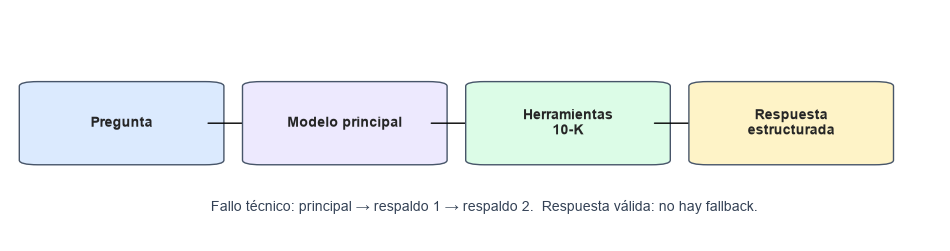

In [2]:
fig, ax = plt.subplots(figsize=(12, 3)); ax.axis('off')
pasos = [('Pregunta', '#dbeafe'), ('Modelo principal', '#ede9fe'), ('Herramientas\n10-K', '#dcfce7'), ('Respuesta\nestructurada', '#fef3c7')]
for i, (etiqueta, color) in enumerate(pasos):
    x = .03 + i*.24
    ax.add_patch(FancyBboxPatch((x,.35), .18,.32, boxstyle='round,pad=.02', facecolor=color, edgecolor='#475569'))
    ax.text(x+.09,.51,etiqueta,ha='center',va='center',weight='bold')
    if i < 3: ax.add_patch(FancyArrowPatch((x+.18,.51),(x+.235,.51),arrowstyle='->',mutation_scale=15))
ax.text(.51,.13,'Fallo técnico: principal → respaldo 1 → respaldo 2.  Respuesta válida: no hay fallback.',ha='center',color='#334155')
plt.show()


## 2. Contrato: una respuesta que se puede comprobar

La respuesta no es texto libre. Los ocho campos obligatorios permiten comprobar cifra, unidad, empresa, ejercicio y evidencia. Una cifra sólo procede de XBRL; si falta realmente en el corpus se devuelve `cifra=None` y `fuente="ninguna"`.

La visual enseña los campos que debe completar cualquier modelo de la cascada. Así cambiar de proveedor no cambia el formato que consume el resto del proyecto.


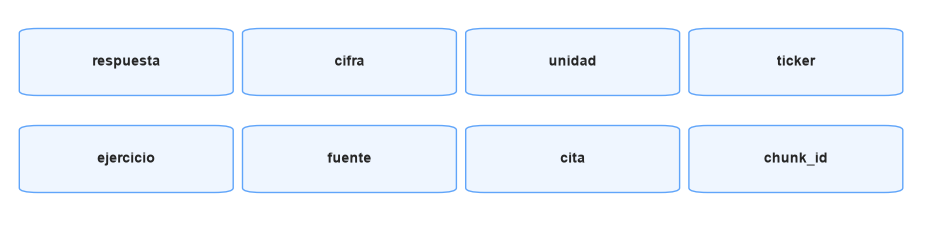

In [3]:
campos = list(agente.RespuestaFinanciera.model_fields)[:8]
fig, ax = plt.subplots(figsize=(12, 3)); ax.axis('off')
for i, campo in enumerate(campos):
    fila, col = divmod(i, 4); x, y = .03+col*.24, .65-fila*.42
    ax.add_patch(FancyBboxPatch((x,y),.19,.25,boxstyle='round,pad=.02',facecolor='#eff6ff',edgecolor='#60a5fa'))
    ax.text(x+.095,y+.125,campo,ha='center',va='center',fontsize=10,weight='bold')
plt.show()


## 3. Herramientas antes que intuiciones

Esta tabla es la regla operativa que recibe el agente. **Cifra exacta** usa XBRL; **explicación o riesgo** busca texto; una sección completa sólo se lee cuando la búsqueda no localiza el pasaje. Preguntar por cobertura es el único caso de `list_available`.

El coste relativo no es precio en dólares: indica cuánta información devuelve cada herramienta y ayuda a evitar pedir una sección entera innecesariamente.


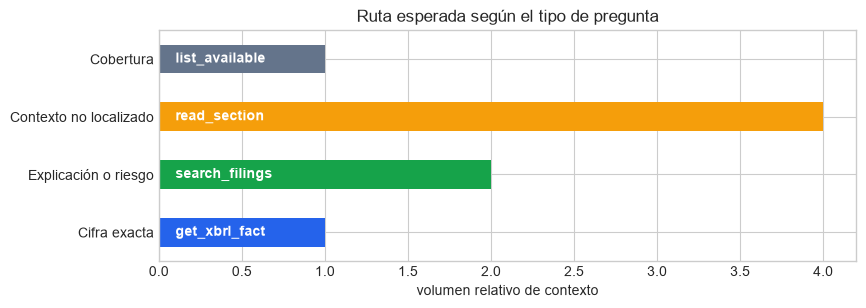

In [4]:
rutas = pd.DataFrame([
 ['Cifra exacta', 'get_xbrl_fact', 1], ['Explicación o riesgo', 'search_filings', 2],
 ['Contexto no localizado', 'read_section', 4], ['Cobertura', 'list_available', 1]],
 columns=['necesidad','herramienta','coste relativo'])
ax=rutas.set_index('necesidad')['coste relativo'].plot.barh(color=['#2563eb','#16a34a','#f59e0b','#64748b'], figsize=(9,3))
ax.set_xlabel('volumen relativo de contexto'); ax.set_ylabel(''); ax.set_title('Ruta esperada según el tipo de pregunta')
for i, herramienta in enumerate(rutas['herramienta']): ax.text(.1,i,herramienta,va='center',color='white',weight='bold')
plt.show()


## 4. Baseline oficial: un modelo, una referencia estable

`construir_agente("baseline")` une el modelo fijado en configuración, las cuatro herramientas, memoria por hilo y `ToolStrategy(RespuestaFinanciera)`. Se mantiene sin cascada para que las evaluaciones futuras comparen exactamente el mismo punto de partida.

La función `ejecutar()` crea un hilo nuevo, captura errores y devuelve además de la respuesta: llamadas de herramientas, tokens comunicados por el proveedor, USD si el proveedor lo informa y latencia.


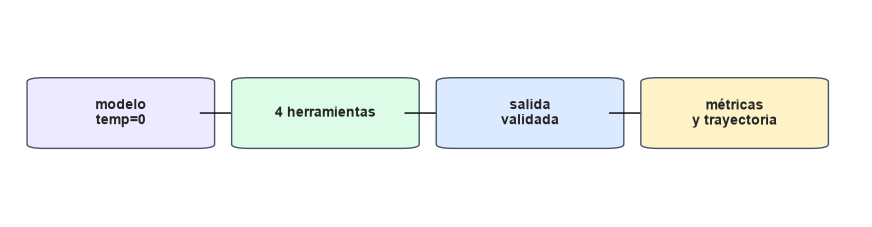

Herramientas registradas: list_available, get_xbrl_fact, search_filings, read_section


In [5]:
fig, ax = plt.subplots(figsize=(11,2.7)); ax.axis('off')
componentes=[('modelo\ntemp=0','#ede9fe'),('4 herramientas','#dcfce7'),('salida\nvalidada','#dbeafe'),('métricas\ny trayectoria','#fef3c7')]
for i,(texto,color) in enumerate(componentes):
    x=.04+i*.24; ax.add_patch(FancyBboxPatch((x,.35),.18,.3,boxstyle='round,pad=.02',facecolor=color,edgecolor='#475569'))
    ax.text(x+.09,.5,texto,ha='center',va='center',weight='bold')
    if i<3: ax.add_patch(FancyArrowPatch((x+.18,.5),(x+.235,.5),arrowstyle='->',mutation_scale=14))
plt.show()
print('Herramientas registradas:', ', '.join(h.name for h in TOOLS))


## 5. Prueba de humo con OpenRouter: una sola pregunta

Esta es la primera llamada real recomendada. Se ejecuta únicamente si `EJECUTAR_API=True` y existe `OPENROUTER_API_KEY` en el entorno o en `.env`, que está ignorado por Git. No muestra ni guarda la clave.

Cómo leer la salida: `respuesta` es el resultado para la persona; `tool_calls` permite comprobar la ruta; `modelo`, `latencia_s`, `uso_mensajes` y `usd_openrouter` documentan el coste operativo. Si no hay clave, la celda explica cómo activarla y no hace red.


In [6]:
pregunta_humo = 'Compare revenue de MSFT entre FY2024 y FY2025 y explique la variación.'
if EJECUTAR_API and config.cargar_clave():
    humo = agente.ejecutar(pregunta_humo)
    display(pd.Series({k: humo[k] for k in ['modelo','latencia_s','usd_openrouter','n_llamadas','error']}))
    display(humo['respuesta'])
    display(pd.DataFrame(humo['tool_calls']))
else:
    print('Sin llamada: deja EJECUTAR_API=False para el modo local. Para probar: añade OPENROUTER_API_KEY a .env y activa la variable.')


Sin llamada: deja EJECUTAR_API=False para el modo local. Para probar: añade OPENROUTER_API_KEY a .env y activa la variable.


## 6. Banco de candidatos: medir antes de elegir

La cascada no se decide por fama. Esta lista admite hasta diez modelos de OpenRouter y las mismas preguntas controladas para todos. Se mide esquema válido, ruta esperada, abstención, latencia, tokens, USD y error.

Con `EJECUTAR_API=True`, cada candidato se ejecuta de forma aislada como baseline. Si no hay clave, no se simulan resultados: el banco queda vacío.


In [7]:
CANDIDATOS = [
    # Sustituye por IDs vigentes de OpenRouter tras consultar su catálogo; máximo diez.
    'openrouter/free',
]
CANDIDATOS = CANDIDATOS[:10]
CASOS_BANCO = pd.DataFrame([
 ['Revenue NVDA FY2024','get_xbrl_fact','xbrl'],
 ['Riesgo de IA en MSFT FY2025','search_filings','texto'],
 ['Gross profit de AMZN','get_xbrl_fact','ninguna'],
 ['Empresa/año fuera del corpus','list_available','ninguna'],
], columns=['pregunta','ruta esperada','fuente esperada'])
display(CASOS_BANCO)
print(f'{len(CANDIDATOS)} candidato(s) configurado(s); máximo permitido: 10.')


,pregunta,ruta esperada,fuente esperada
0,Revenue NVDA FY2024,get_xbrl_fact,xbrl
1,Riesgo de IA en MSFT FY2025,search_filings,texto
2,Gross profit de AMZN,get_xbrl_fact,ninguna
3,Empresa/año fuera del corpus,list_available,ninguna


1 candidato(s) configurado(s); máximo permitido: 10.


## 7. Selección: fiabilidad antes que inteligencia aislada

Tras ejecutar el banco con API, cada fila será una interacción modelo–pregunta. Un modelo que no cumple el esquema, usa una ruta errónea o no se abstiene no debe encabezar la cascada aunque sea rápido.

La puntuación propuesta da prioridad a completar respuestas válidas y a respetar el contrato. Coste y latencia sólo desempatan. La primera terna se ordena como principal, respaldo 1 y respaldo 2.


In [8]:
PESOS = {'esquema_valido': .35, 'ruta_correcta': .30, 'abstencion_correcta': .20, 'sin_error': .15}
filas_banco = []
if EJECUTAR_API and config.cargar_clave():
    for modelo in CANDIDATOS:
        for _, caso in CASOS_BANCO.iterrows():
            resultado = agente.ejecutar(caso['pregunta'], sistema='baseline', modelo=modelo)
            respuesta = resultado['respuesta']
            ruta = resultado['tool_calls'][0]['name'] if resultado['tool_calls'] else None
            filas_banco.append({'modelo': modelo, 'pregunta': caso['pregunta'],
                'esquema_valido': isinstance(respuesta, agente.RespuestaFinanciera),
                'ruta_correcta': ruta == caso['ruta esperada'],
                'abstencion_correcta': respuesta.fuente == caso['fuente esperada'],
                'sin_error': resultado['error'] is None, 'latencia_s': resultado['latencia_s'],
                'tokens': resultado['uso_mensajes']['total_tokens'], 'usd': resultado['usd_openrouter'], 'error': resultado['error']})
resultados_banco = pd.DataFrame(filas_banco, columns=['modelo','pregunta','esquema_valido','ruta_correcta','abstencion_correcta','sin_error','latencia_s','tokens','usd','error'])
if resultados_banco.empty:
    resumen = pd.DataFrame()
    print('Aún no hay resultados reales: activa EJECUTAR_API para ejecutar el banco.')
else:
    resumen = resultados_banco.groupby('modelo').mean(numeric_only=True)
    resumen['puntuacion'] = sum(resumen[k] * peso for k, peso in PESOS.items())
    resumen = resumen.sort_values(['puntuacion','latencia_s'], ascending=[False, True])
    display(resumen)
    display(resultados_banco)


Aún no hay resultados reales: activa EJECUTAR_API para ejecutar el banco.


## 8. Cascada de disponibilidad: qué se guarda y qué no hace

Los tres mejores candidatos se ordenan como principal y dos respaldos. El proveedor pasa al siguiente sólo por fallo técnico, límite de tasa, indisponibilidad o rechazo. Una respuesta de baja calidad pero técnicamente válida **no** dispara fallback: eso se controla con golden set, evaluación y guardrails.

La ejecución registra modelo solicitado, modelo real, posición y si hubo fallback. Sin estas columnas no se puede demostrar que la disponibilidad adicional compense coste o latencia.


Orden seleccionado: pendiente de resultados del banco


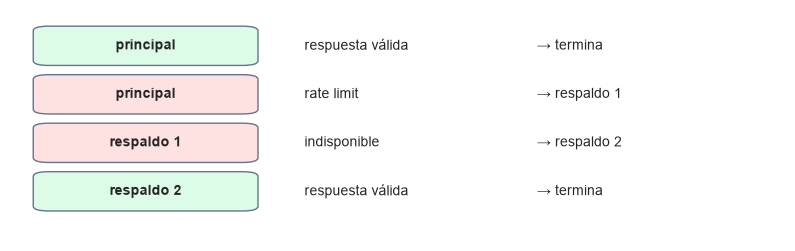

,modelo intentado,resultado técnico,siguiente paso,hubo fallback
0,principal,respuesta válida,termina,False
1,principal,rate limit,respaldo 1,True
2,respaldo 1,indisponible,respaldo 2,True
3,respaldo 2,respuesta válida,termina,True


In [9]:
CASCADA_PROPUESTA = resumen.index[:3].tolist() if not resumen.empty else []
print('Orden seleccionado:', CASCADA_PROPUESTA or 'pendiente de resultados del banco')
traza_cascada = pd.DataFrame([['principal', 'respuesta válida', 'termina', False], ['principal', 'rate limit', 'respaldo 1', True], ['respaldo 1', 'indisponible', 'respaldo 2', True], ['respaldo 2', 'respuesta válida', 'termina', True]], columns=['modelo intentado','resultado técnico','siguiente paso','hubo fallback'])
fig, ax=plt.subplots(figsize=(10,3)); ax.axis('off')
for i,row in traza_cascada.iterrows():
    y=.78-i*.21; color='#dcfce7' if row['resultado técnico']=='respuesta válida' else '#fee2e2'
    ax.add_patch(FancyBboxPatch((.05,y),.25,.13,boxstyle='round,pad=.02',facecolor=color,edgecolor='#64748b'))
    ax.text(.175,y+.065,row['modelo intentado'],ha='center',va='center',weight='bold'); ax.text(.38,y+.065,row['resultado técnico'],va='center'); ax.text(.68,y+.065,'→ '+row['siguiente paso'],va='center')
plt.show(); display(traza_cascada)


## 9. Métricas: comparar modelo único y cascada sin engañarse

La cascada se ejecuta sobre los mismos casos tras elegir tres modelos. Se informa de completadas, ruta correcta, latencia, USD, fallbacks y modelo real. La mejora de disponibilidad no justifica una caída de calidad financiera.


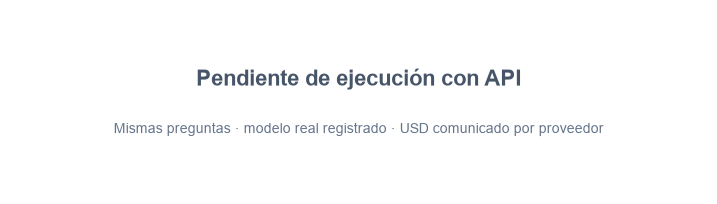

,sistema,preguntas,completadas_%,ruta_correcta_%,latencia_mediana_s,usd_total,fallbacks


In [10]:
filas_cascada = []
if EJECUTAR_API and config.cargar_clave() and len(CASCADA_PROPUESTA) == 3:
    for _, caso in CASOS_BANCO.iterrows():
        resultado = agente.ejecutar(caso['pregunta'], sistema='cascada', modelo=CASCADA_PROPUESTA[0], fallbacks=CASCADA_PROPUESTA[1:])
        ruta = resultado['tool_calls'][0]['name'] if resultado['tool_calls'] else None
        filas_cascada.append({'completada': resultado['error'] is None, 'ruta_correcta': ruta == caso['ruta esperada'], 'latencia_s': resultado['latencia_s'], 'usd': resultado['usd_openrouter'], 'hubo_fallback': resultado['hubo_fallback'], 'modelo_real': resultado['modelo_real']})
resultados_cascada = pd.DataFrame(filas_cascada)
comparacion = pd.DataFrame(columns=['sistema','preguntas','completadas_%','ruta_correcta_%','latencia_mediana_s','usd_total','fallbacks'])
if not resultados_cascada.empty:
    comparacion.loc[0] = ['cascada', len(resultados_cascada), 100*resultados_cascada.completada.mean(), 100*resultados_cascada.ruta_correcta.mean(), resultados_cascada.latencia_s.median(), resultados_cascada.usd.sum(min_count=1), int(resultados_cascada.hubo_fallback.sum())]
    display(resultados_cascada)
fig, ax = plt.subplots(figsize=(9,2.4)); ax.axis('off')
ax.text(.5,.62,'Resultados reales al activar API' if not comparacion.empty else 'Pendiente de ejecución con API',ha='center',va='center',fontsize=16,weight='bold',color='#475569')
ax.text(.5,.35,'Mismas preguntas · modelo real registrado · USD comunicado por proveedor',ha='center',va='center',color='#64748b')
plt.show(); display(comparacion)


## 10. Comprobación local sin red

Estas pruebas verifican el contrato, el fallback de respuesta, hilos independientes y la extracción de trayectoria. No validan calidad financiera ni disponibilidad de proveedores: eso es precisamente lo que medirán el banco y el golden set.

Al terminar en verde, el notebook puede compartirse o revisarse sin clave y sin coste.


In [11]:
import pytest
estado = pytest.main(['-q', str(RAIZ/'tests'/'test_agente.py'), str(RAIZ/'tests'/'test_contratos.py'), '-p', 'no:cacheprovider'])
assert estado == 0
print('✓ Contrato y arnés comprobados sin red.')


.

.

.

.

.

...

.

.

.

                                                             [100%]


============================== warnings summary ===============================
..\..\..\..\..\..\..\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345
  C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; anyio
    self._mark_plugins_for_rewrite(hook, disable_autoload)

..\..\..\..\..\..\..\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345
  C:\Users\Usuario\Downloads\10k-financial-agent\.venv\Lib\site-packages\_pytest\config\__init__.py:1345: PytestAssertRewriteWarning: Module already imported so cannot be rewritten; langsmith
    self._mark_plugins_for_rewrite(hook, disable_autoload)

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
12 passed, 2 warnings in 0.05s
✓ Contrato y arnés comprobados sin red.


## Cierre

El baseline queda como referencia estable. La cascada ya se ejecuta con los tres candidatos mejor puntuados y deja su trazabilidad; deberá evaluarse sobre el golden set antes de declararla mejor.
